In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df = pd.read_csv("placement_predict_50k Dataset.csv")

In [26]:
# Drop 'IsAnomaly' column as it was identified as an irrelevant column earlier
if 'IsAnomaly' in df.columns:
    df = df.drop(columns=['IsAnomaly'])
    print("Dropped 'IsAnomaly' column.")
else:
    print("'IsAnomaly' column not found or already dropped.")


Dropped 'IsAnomaly' column.


In [27]:
# Robust Data Cleaning: Convert to numeric where possible and handle NaNs
# This loop addresses the ValueError by coercing non-numeric values to NaN first.
for col in df.columns:
    if col == 'PlacementStatus':
        continue # Skip the target variable

    # Attempt to convert to numeric, coercing errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Now handle missing values (NaNs), including those potentially created by `pd.to_numeric`
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        # For truly categorical columns (or other object types that remain non-numeric after coercion),
        # fill NaNs with the mode. If mode is empty (all NaNs), fill with a placeholder.
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna('Missing') # Fallback for columns with all NaNs

print("Data cleaning and missing value imputation complete.")


Data cleaning and missing value imputation complete.


In [28]:
# One-Hot Encoding for categorical features
# Dynamically identify all object/category columns that are not the target variable
columns_to_encode = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'PlacementStatus' in columns_to_encode:
    columns_to_encode.remove('PlacementStatus')

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
print(f"One-hot encoding applied. New DataFrame shape: {df_encoded.shape}")
print(f"Columns after encoding: {df_encoded.columns.tolist()[:5]}...{df_encoded.columns.tolist()[-5:]}")


One-hot encoding applied. New DataFrame shape: (50000, 31)
Columns after encoding: ['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream']...['MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'Salary Package']


In [29]:
# Split data into features (X) and target (y)
X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (50000, 30)
Target (y) shape: (50000,)


In [30]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (40000, 30)
X_test shape: (10000, 30)
y_train shape: (40000,)
y_test shape: (10000,)


In [31]:
# Initialize and train a Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")


Decision Tree Classifier trained successfully.



Model Evaluation:
Accuracy: 0.9979

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      3429
           1       1.00      1.00      1.00      6571

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



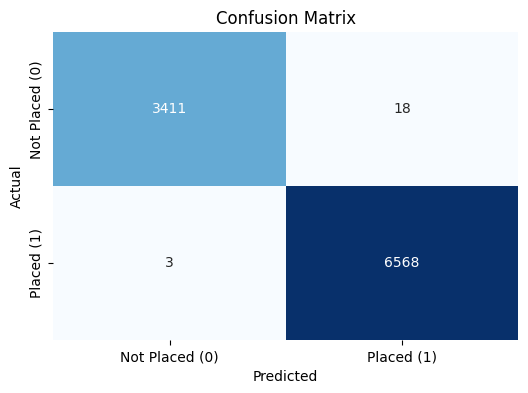

In [32]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Placed (0)', 'Placed (1)'],
            yticklabels=['Not Placed (0)', 'Placed (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Saved decision tree visualization to 'decision_tree.png'.


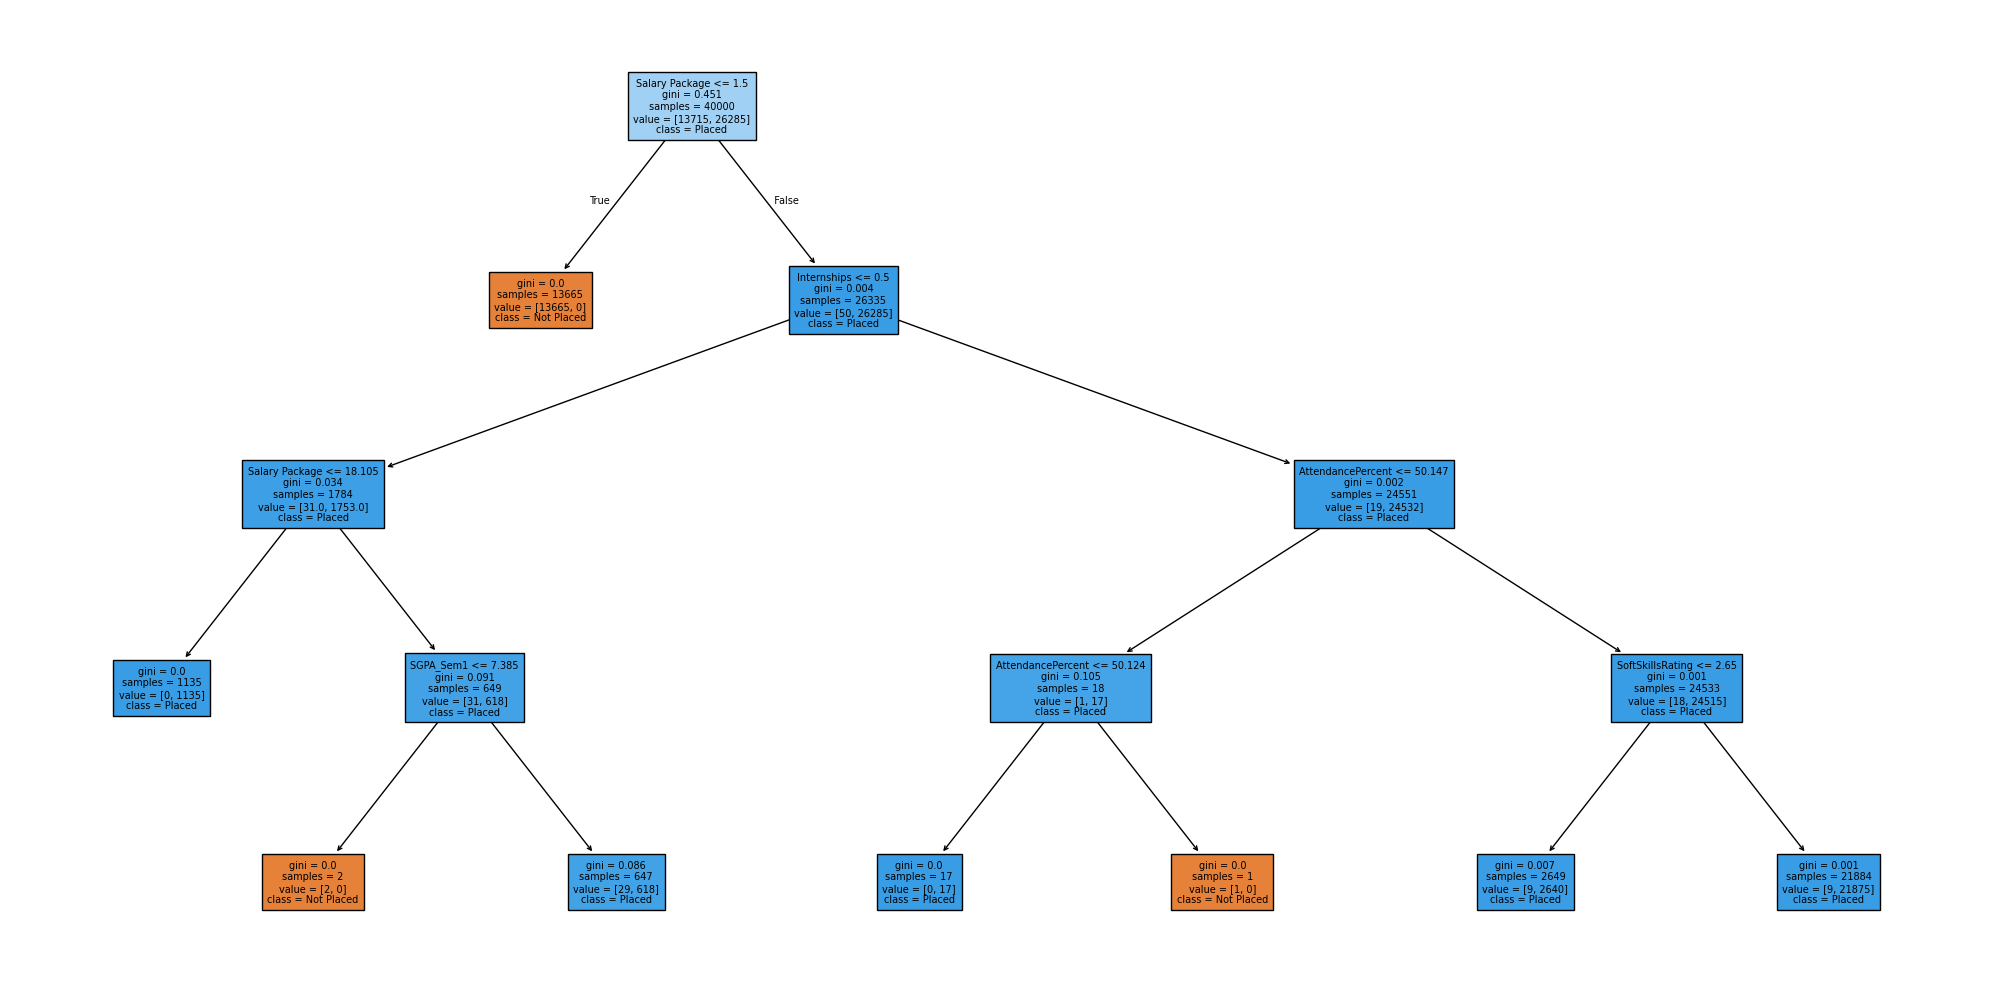

In [33]:
# Plot the Decision Tree (optional, but useful for understanding)
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Not Placed', 'Placed'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved decision tree visualization to 'decision_tree.png'.")


In [21]:
print("Sample of the dataset:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Class balance:\n{df['PlacementStatus'].value_counts()}")

Sample of the dataset:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4 

In [22]:
TARGET = "Placed"
DROP_COLS = ["StudentID"]

In [34]:
TARGET = "PlacementStatus" # Corrected target column name
feature_names = [c for c in df.columns if c not in [TARGET] + DROP_COLS]
X = df[feature_names].values
y = df[TARGET].values

In [36]:
RANDOM_STATE = 42

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [38]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

In [39]:
y_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nOOB score: {rf.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))


OOB score: 0.9988
Test accuracy: 0.9980

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3422
           1       1.00      1.00      1.00      6578

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [40]:
print("Feature importances:")
for name, importance in sorted(
    zip(feature_names, rf.feature_importances_), key=lambda x: -x[1]
):
    print(f"  {name}: {importance:.4f}")
rf = RandomForestClassifier(
    n_estimators=100,
max_features="sqrt",
oob_score=True,
random_state=RANDOM_STATE,
)

Feature importances:
  Salary Package: 0.3950
  SGPA_Sem6: 0.0679
  SGPA_Sem5: 0.0668
  SGPA_Sem7: 0.0625
  SGPA_Sem8: 0.0534
  CGPA: 0.0487
  SGPA_Sem4: 0.0472
  SGPA_Sem2: 0.0415
  MockInterviewScore: 0.0349
  SGPA_Sem3: 0.0309
  CodingTestScore: 0.0290
  Projects: 0.0258
  SoftSkillsRating: 0.0257
  AptitudeTestScore: 0.0171
  SGPA_Sem1: 0.0167
  Certifications: 0.0133
  Internships: 0.0100
  AttendancePercent: 0.0094
  Workshops: 0.0023
  Publications: 0.0015
  ExtraCurricular: 0.0004
  Gender: 0.0000
  City: 0.0000
  CollegeTier: 0.0000
  Stream: 0.0000
  Specialisation: 0.0000
  Hostel: 0.0000
  HistoryOfBacklogs: 0.0000
  CGPA_Tier: 0.0000
